In [1]:
from pathlib import Path
from typing import Dict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DOMAIN_NAME = "blocksworld"
TS_NAME = "TS_Per"
TS_DIR = f"{TS_NAME}_noisy"

VERSIONS = ["v1", "v2"]
NOISE_LEVELS = [5, 10, 20, 30]

FILE_NAME = "overall-report.csv"

In [2]:
def load_data() -> Dict[str, Dict[int, pd.DataFrame]]:
    data = {}

    for version in VERSIONS:
        version_data = {}

        base_path = Path(
            f"../testsets/{version}/{TS_DIR}/{DOMAIN_NAME}/report"
        )

        for noise in NOISE_LEVELS:
            file_path = (
                base_path
                / f"{DOMAIN_NAME}-noisy_{noise}"
                / FILE_NAME
            )

            version_data[noise] = pd.read_csv(
                file_path,
                delimiter=";"
            )

        data[version] = version_data

    return data


data = load_data()

In [3]:
def calculate_noise_stats(df: pd.DataFrame):
    noise = df["Noise applied"]

    return {
        "Total Problems": len(df),
        "Min Noise": noise.min(),
        "Max Noise": noise.max(),
        "Mean Noise": noise.mean(),
        "Std Noise": noise.std(),
        "% No Noise": (noise == 0).mean() * 100,
        "% Full Noise": (noise == 1).mean() * 100,
    }

In [4]:
summary_rows = []

for version, version_data in data.items():
    for noise_level, df in version_data.items():
        stats = calculate_noise_stats(df)

        summary_rows.append({
            "Version": version,
            "Noise Level": f"{noise_level}%",
            **stats
        })

summary_df = pd.DataFrame(summary_rows)

summary_df["% No Noise"] = (
    summary_df["% No Noise"]
    .map(lambda x: f"{x:.2f}%")
)

summary_df["% Full Noise"] = (
    summary_df["% Full Noise"]
    .map(lambda x: f"{x:.2f}%")
)

summary_df

,Version,Noise Level,Total Problems,Min Noise,Max Noise,Mean Noise,Std Noise,% No Noise,% Full Noise
0,v1,5%,1076,0.0,1.000000,0.047917,0.113762,73.70%,0.37%
1,v1,10%,1076,0.0,1.000000,0.098743,0.174612,60.41%,1.58%
2,v1,20%,1076,0.0,1.000000,0.204128,0.237446,39.50%,4.09%
3,v1,30%,1076,0.0,1.000000,0.294501,0.271722,29.37%,6.04%
4,v2,5%,1076,0.0,0.333333,0.044091,0.082811,69.24%,0.00%
5,v2,10%,1076,0.0,0.333333,0.080508,0.101378,52.32%,0.00%
6,v2,20%,1076,0.0,0.333333,0.140719,0.114356,35.04%,0.00%
7,v2,30%,1076,0.0,0.400000,0.208758,0.141085,28.90%,0.00%


In [5]:
plot_df = pd.concat(
    [
        df.assign(
            Version=version,
            Noise_Level=f"{noise}%"
        )
        for version, version_data in data.items()
        for noise, df in version_data.items()
    ],
    ignore_index=True
)

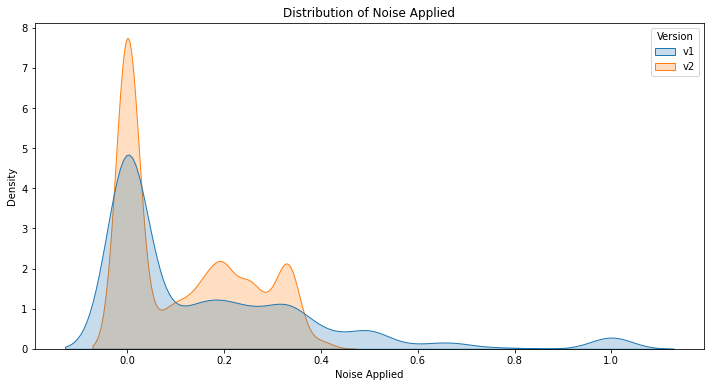

In [6]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=plot_df,
    x="Noise applied",
    hue="Version",
    fill=True,
    common_norm=False
)

plt.title("Distribution of Noise Applied")
plt.xlabel("Noise Applied")
plt.ylabel("Density")

plt.show()

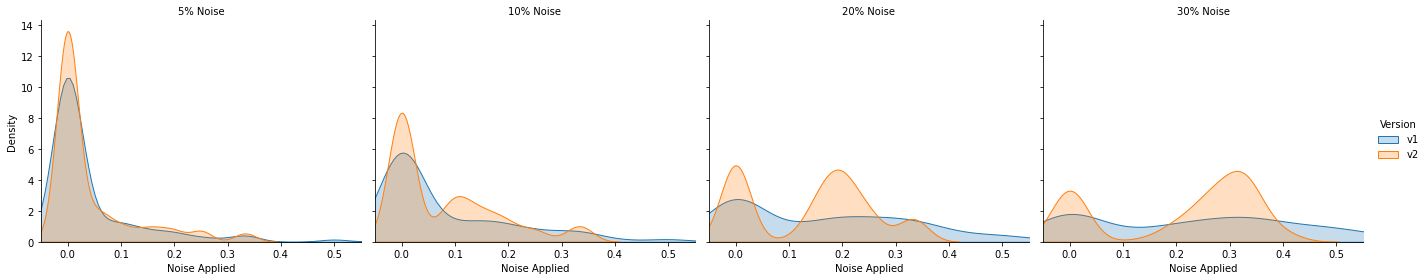

In [7]:
g = sns.FacetGrid(
    plot_df,
    col="Noise_Level",
    hue="Version",
    col_order=[f"{n}%" for n in NOISE_LEVELS],
    height=4,
    aspect=1.2,
    sharey=True
)

g.map(sns.kdeplot, "Noise applied", fill=True)
g.add_legend()

g.set_axis_labels("Noise Applied", "Density")
g.set_titles("{col_name} Noise")

g.set(xlim=(-0.05, 0.55))

plt.show()

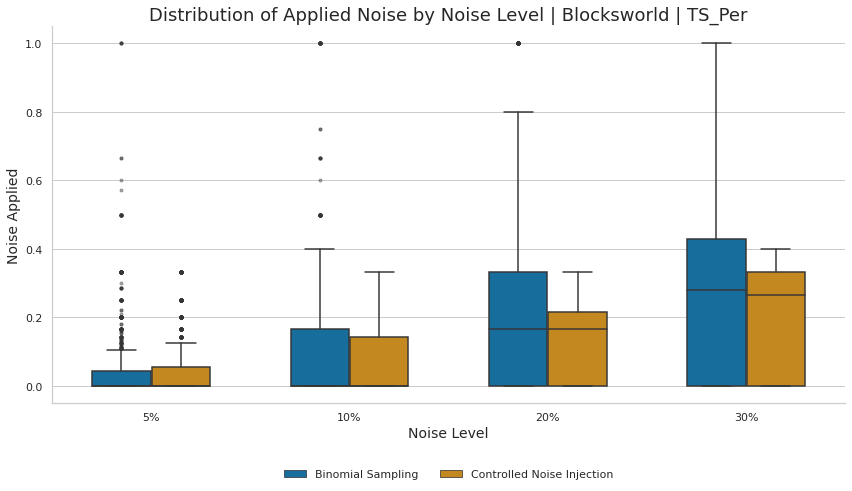

In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    data=plot_df,
    x="Noise_Level",
    y="Noise applied",
    hue="Version",
    palette="colorblind",
    width=0.6,
    showmeans=False,
    meanprops={
        "marker": "D",
        "markerfacecolor": "black",
        "markeredgecolor": "white",
        "markersize": 6
    },
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.4
    }
)

sns.despine()

plt.title(f"Distribution of Applied Noise by Noise Level | {DOMAIN_NAME.capitalize()} | {TS_NAME}", fontsize=18)
plt.xlabel("Noise Level", fontsize=14)
plt.ylabel("Noise Applied", fontsize=14)

# Replace legend labels
handles, labels = ax.get_legend_handles_labels()
new_labels = [
    "Binomial Sampling",
    "Controlled Noise Injection"
]

ax.legend(
    handles,
    new_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),  # Centered below the axes
    ncol=2,                       # Put both entries on one row
    frameon=False                 # Cleaner appearance
)

plt.tight_layout()
plt.show()

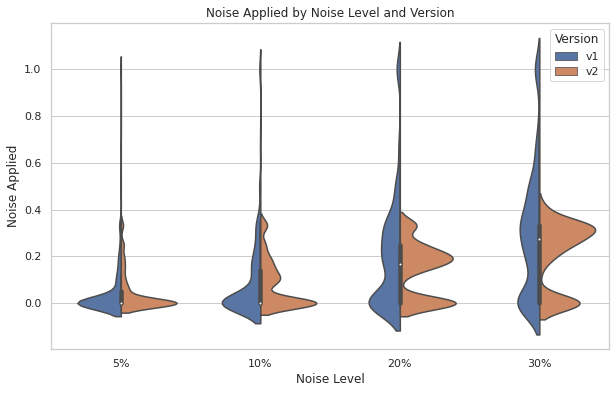

In [9]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_df,
    x="Noise_Level",
    y="Noise applied",
    hue="Version",
    split=True
)

plt.title("Noise Applied by Noise Level and Version")
plt.xlabel("Noise Level")
plt.ylabel("Noise Applied")

plt.show()

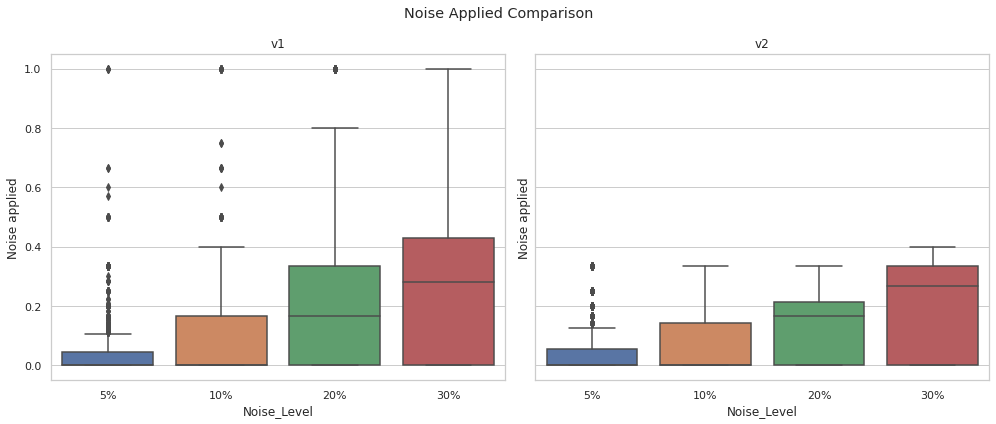

In [10]:
fig, axes = plt.subplots(
    1,
    len(VERSIONS),
    figsize=(14, 6),
    sharey=True
)

for ax, version in zip(axes, VERSIONS):

    sns.boxplot(
        data=plot_df[plot_df["Version"] == version],
        x="Noise_Level",
        y="Noise applied",
        ax=ax
    )

    ax.set_title(version)

plt.suptitle("Noise Applied Comparison")
plt.tight_layout()

plt.show()